# Exact Discretization of a Mass–Spring–Damper System

This notebook converts the continuous-time mass–spring–damper model into an exact discrete-time state-space model.

The continuous-time system is

$$
\dot{\mathbf{x}}(t)
=
A\mathbf{x}(t)+Bf(t)
$$

with the state vector

$$
\mathbf{x}(t)
=
\begin{bmatrix}
x(t) \\
v(t)
\end{bmatrix}
$$

The exact discrete-time model is

$$
\mathbf{x}_{k+1}
=
A_d\mathbf{x}_k+B_df_k
$$

where

$$
A_d=e^{A\Delta t}
$$

and, for a zero-order-hold input,

$$
B_d
=
\int_0^{\Delta t}
e^{A\tau}B\,d\tau
$$

The objective is to calculate $A_d$ and $B_d$, simulate the discrete model, and compare it with the approximate Forward Euler discretization.

In [5]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.linalg import expm


# Physical parameters
m = 1.0       # Mass [kg]
b = 1.0       # Damping coefficient [N·s/m]
k = 10.0      # Spring stiffness [N/m]

# Input
force = 1.0   # Constant force [N]

# Initial conditions
x0 = 0.0      # Initial position [m]
v0 = 0.0      # Initial velocity [m/s]

# Simulation settings
dt = 0.01     # Sampling time [s]
t_final = 10.0

In [6]:
# Continuous-time state matrix
A = np.array([
    [0.0, 1.0],
    [-k / m, -b / m]
])

# Continuous-time input matrix
B = np.array([
    [0.0],
    [1.0 / m]
])

# Initial state: [position, velocity]
state_initial = np.array([
    [x0],
    [v0]
])

print("Continuous-time A matrix:")
print(A)

print("\nContinuous-time B matrix:")
print(B)

print("\nInitial state:")
print(state_initial)

Continuous-time A matrix:
[[  0.   1.]
 [-10.  -1.]]

Continuous-time B matrix:
[[0.]
 [1.]]

Initial state:
[[0.]
 [0.]]


In [7]:
print(f"A shape: {A.shape}")
print(f"B shape: {B.shape}")
print(f"Initial state shape: {state_initial.shape}")

A shape: (2, 2)
B shape: (2, 1)
Initial state shape: (2, 1)


## Exact Discretization Using the Augmented Matrix

The continuous-time system is

$$
\dot{\mathbf{x}}(t)
=
A\mathbf{x}(t)+Bf(t)
$$

The equivalent discrete-time model is

$$
\mathbf{x}_{k+1}
=
A_d\mathbf{x}_k+B_df_k
$$

For a sampling time $\Delta t$, the exact discrete state-transition matrix is

$$
A_d=e^{A\Delta t}
$$

Assuming that the input is constant during each sampling interval, the exact discrete input matrix is

$$
B_d
=
\int_0^{\Delta t}
e^{A\tau}B\,d\tau
$$

A constant input between two sampling instants is called a zero-order-hold input.

Instead of calculating $A_d$ and $B_d$ separately, we construct the augmented matrix

$$
M
=
\begin{bmatrix}
A & B \\
0 & 0
\end{bmatrix}
$$

Its matrix exponential has the structure

$$
e^{M\Delta t}
=
\begin{bmatrix}
A_d & B_d \\
0 & 1
\end{bmatrix}
$$

Therefore:

- the upper-left block contains $A_d$,
- the upper-right block contains $B_d$.

In [16]:
# Construct the augmented matrix 

# Number of state variables 
num_states = A.shape[0]

# Number of input variables
num_inputs = B.shape[1]

# Construct the augmented continous-time matrix 

augmented_matrix = np.block([[A,B], [np.zeros((num_inputs, num_states)), np.zeros((num_inputs, num_inputs))]])

print("Augmented continous-time matrix")
print(augmented_matrix)

print(f"\nAugmented matrix shape: {augmented_matrix.shape}")

Augmented continous-time matrix
[[  0.   1.   0.]
 [-10.  -1.   1.]
 [  0.   0.   0.]]

Augmented matrix shape: (3, 3)


In [ ]:
# Calculate the augmented matrix exponential 
augmented_discrete= expm(augmented_matrix * dt)

# Extract the exact discrete-time matrices 
A_discrete = augmented_discrete[:num_states, :num_states]
B_discrete = augmented_discrete[:num_states, num_states:]

print("Exact discrete-time A matrix:")
print(A_discrete)

print("\nExact discrete-time B matrix:")
print(B_discrete)

print("\nMatrix dimentsions:")
print(f"A_discrete shape: {A_discrete.shape}")
print(f"B_discrete shape: {B_discrete.shape}")

Exact discrete-time A matrix:
[[ 0.9995017   0.00994851]
 [-0.09948508  0.9895532 ]]

Exact discrete-time B matrix:
[[4.98295993e-05]
 [9.94850798e-03]]

Matrix dimentsions:
A_discrete shape: (2, 2)
B_discrete shape: (2, 1)


## Exact Discrete-Time Simulation

The exact discrete-time state-space model is

$$
\mathbf{x}_{k+1}
=
A_d\mathbf{x}_k+B_df_k
$$

where

$$
\mathbf{x}_k
=
\begin{bmatrix}
x_k \\
v_k
\end{bmatrix}
$$

contains the position and velocity at sampling instant $k$.

Unlike Forward Euler, this equation does not explicitly calculate the continuous-time derivative.

Forward Euler uses

$$
\mathbf{x}_{k+1}
=
\mathbf{x}_k
+
\Delta t
\left(
A\mathbf{x}_k+Bf_k
\right)
$$

whereas the exact discrete model uses

$$
\mathbf{x}_{k+1}
=
A_d\mathbf{x}_k+B_df_k
$$

The matrices $A_d$ and $B_d$ already contain the effect of the continuous-time dynamics over one complete sampling interval.

For this simulation, the input force is constant:

$$
f_k=1\ \text{N}
$$

for every sampling instant.

In [18]:
# Number of discrete time intervals 
num_steps = int(t_final / dt)

# Time vector including the initial and final times 
time = np.linspace(0.0, t_final, num_steps + 1)

print(f"Number of intervals: {num_steps}")
print(f"Number of time samples: {len(time)}")
print(f"Initial time: {time[0]:.2f} s")
print(f"Final time: {time[-1]:.2f} s")
print(f"Sampling time: {time[1] - time[0]:.4f} s")

Number of intervals: 1000
Number of time samples: 1001
Initial time: 0.00 s
Final time: 10.00 s
Sampling time: 0.0100 s


In [19]:
# Allocate memory for the exact discrete state history 
state_history_exact = np.zeros((num_states, len(time)))

# Store the initial condition in the first column 
state_history_exact[:,0] = state_initial[:, 0]

print(f"State history shape: {state_history_exact.shape}")
print("\nInitial stored state:")
print(state_history_exact[:,0])

State history shape: (2, 1001)

Initial stored state:
[0. 0.]


In [20]:
# Exact discrete-time simulation
for step in range(num_steps):
    # Current state vector: [position, velocity]
    current_state = state_history_exact[:, step]

    # Exact discrete-time state update
    next_state = (A_discrete @ current_state + B_discrete[:,0] * force)

    # Store the next state
    state_history_exact[:, step + 1] = next_state

In [23]:
print("Initial state:")
print(state_history_exact[:, 0])

print("\nState after one exact discrete step:")
print(state_history_exact[:, 1])

print("\nState after two exact discrete steps:")
print(state_history_exact[:, 2])

Initial state:
[0. 0.]

State after one exact discrete step:
[4.98295993e-05 9.94850798e-03]

State after two exact discrete steps:
[0.00019861 0.01978813]


In [24]:
# Extract position and velocity
position_exact = state_history_exact[0, :]
velocity_exact = state_history_exact[1, :]

print(f"Final position: {position_exact[-1]:.6f} m")
print(f"Final velocity: {velocity_exact[-1]:.6f} m/s")

Final position: 0.099359 m
Final velocity: -0.000410 m/s


## Expected Discrete-Time Response

The exact discrete-time model represents the same physical mass–spring–damper system as the continuous-time model.

Therefore, the physical behavior should remain the same:

- the position starts from zero,
- the system oscillates because it is underdamped,
- damping gradually reduces the oscillations,
- the position approaches the static equilibrium,
- the velocity approaches zero.

For a constant input force, the steady-state position is

$$
x_{\mathrm{ss}}=\frac{f}{k}
$$

For this system,

$$
x_{\mathrm{ss}}=\frac{1}{10}=0.1\ \text{m}
$$

At steady state, the velocity is

$$
v_{\mathrm{ss}}=0\ \text{m/s}
$$

The exact discrete-time solution should reach these same steady-state values because discretization changes the mathematical representation, not the underlying physical system.

In [25]:
# Theoretical steady-state values
steady_state_position = force / k
steady_state_velocity = 0.0

print(f"Theoretical steady-state position: {steady_state_position:.4f} m")
print(f"Theoretical steady-state velocity: {steady_state_velocity:.4f} m/s")

Theoretical steady-state position: 0.1000 m
Theoretical steady-state velocity: 0.0000 m/s


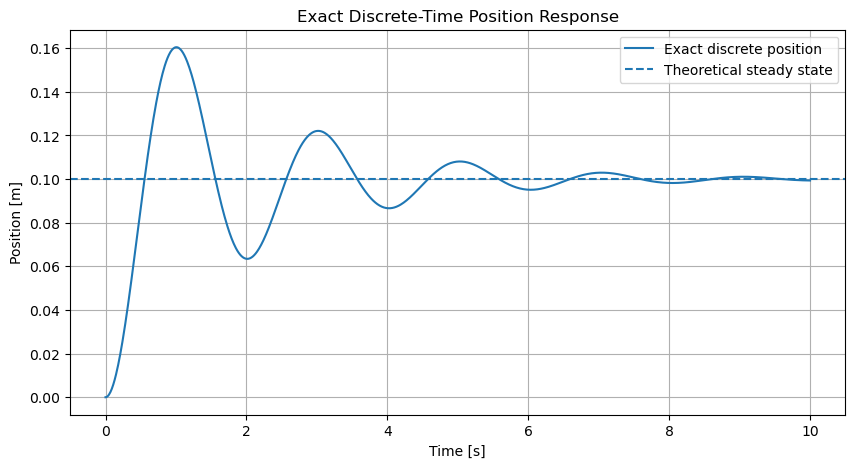

In [26]:
plt.figure(figsize=(10, 5))

plt.plot(
    time,
    position_exact,
    label="Exact discrete position"
)

plt.axhline(
    steady_state_position,
    linestyle="--",
    label="Theoretical steady state"
)

plt.xlabel("Time [s]")
plt.ylabel("Position [m]")
plt.title("Exact Discrete-Time Position Response")
plt.grid(True)
plt.legend()
plt.show()

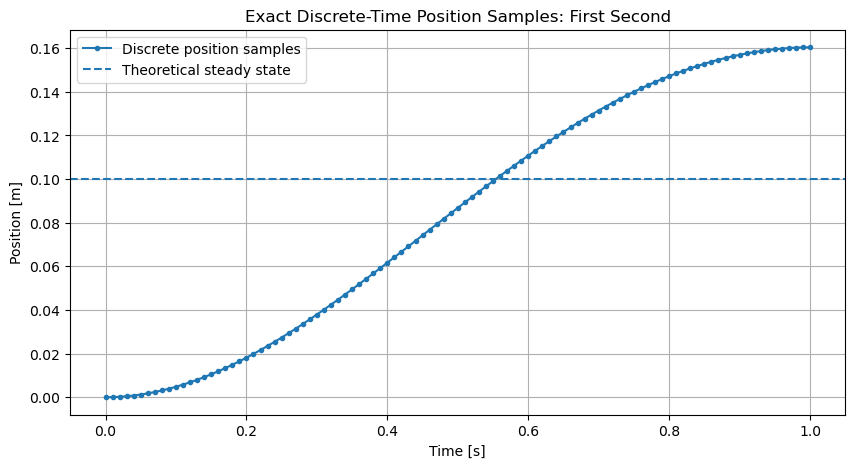

In [27]:
# Select samples from the first second
first_second = time <= 1.0

plt.figure(figsize=(10, 5))

plt.plot(
    time[first_second],
    position_exact[first_second],
    marker="o",
    markersize=3,
    label="Discrete position samples"
)

plt.axhline(
    steady_state_position,
    linestyle="--",
    label="Theoretical steady state"
)

plt.xlabel("Time [s]")
plt.ylabel("Position [m]")
plt.title("Exact Discrete-Time Position Samples: First Second")
plt.grid(True)
plt.legend()
plt.show()

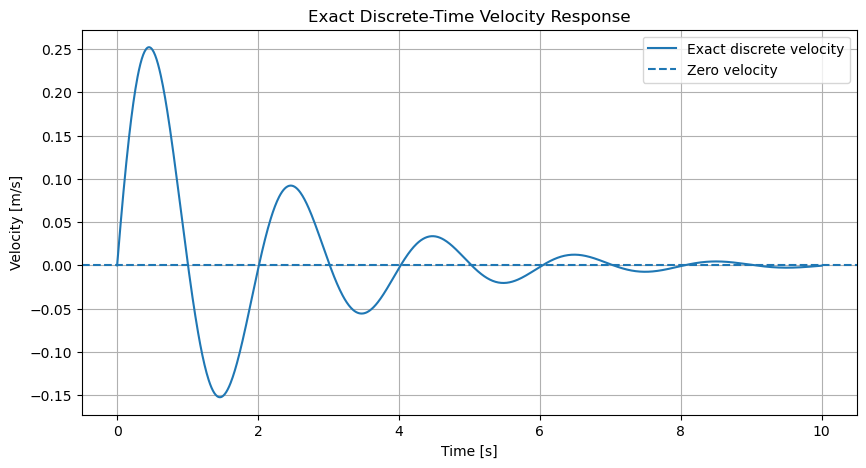

In [28]:
plt.figure(figsize=(10, 5))

plt.plot(
    time,
    velocity_exact,
    label="Exact discrete velocity"
)

plt.axhline(
    steady_state_velocity,
    linestyle="--",
    label="Zero velocity"
)

plt.xlabel("Time [s]")
plt.ylabel("Velocity [m/s]")
plt.title("Exact Discrete-Time Velocity Response")
plt.grid(True)
plt.legend()
plt.show()

In [29]:
final_position_error = abs(
    position_exact[-1] - steady_state_position
)

final_velocity_error = abs(
    velocity_exact[-1] - steady_state_velocity
)

print(f"Final simulated position: {position_exact[-1]:.6f} m")
print(f"Theoretical steady-state position: {steady_state_position:.6f} m")
print(f"Final position error: {final_position_error:.6e} m")

print()

print(f"Final simulated velocity: {velocity_exact[-1]:.6f} m/s")
print(f"Theoretical steady-state velocity: {steady_state_velocity:.6f} m/s")
print(f"Final velocity error: {final_velocity_error:.6e} m/s")

Final simulated position: 0.099359 m
Theoretical steady-state position: 0.100000 m
Final position error: 6.410739e-04 m

Final simulated velocity: -0.000410 m/s
Theoretical steady-state velocity: 0.000000 m/s
Final velocity error: 4.095173e-04 m/s


## Conclusion

The continuous-time mass–spring–damper model was converted into the exact discrete-time form

$$
\mathbf{x}_{k+1}
=
A_d\mathbf{x}_k+B_df_k
$$

where

$$
A_d=e^{A\Delta t}
$$

and

$$
B_d
=
\int_0^{\Delta t}
e^{A\tau}B\,d\tau
$$

The matrices $A_d$ and $B_d$ were calculated using the augmented matrix exponential under the zero-order-hold input assumption.

The discrete simulation produced the final position

$$
x(10)=0.099359\ \text{m}
$$

compared with the theoretical steady-state position

$$
x_{\mathrm{ss}}=0.100000\ \text{m}
$$

The final position error was

$$
|x(10)-x_{\mathrm{ss}}|
=
6.410739\times10^{-4}\ \text{m}
$$

The final velocity was

$$
v(10)=-0.000410\ \text{m/s}
$$

with a velocity magnitude error of

$$
4.095173\times10^{-4}\ \text{m/s}
$$

These small differences occur because the simulation ends at $10$ seconds while a small residual oscillation is still present. The system is approaching equilibrium, but it has not reached the steady-state values exactly.

The exact discrete-time model captures the continuous system response at the sampling instants, subject to the zero-order-hold input assumption and normal floating-point numerical precision.